# Model fylogenetische diversiteit

## Packages inladen

In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    train_test_split, cross_val_score, GroupKFold,
)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
DATA_DIR = pathlib.Path(r"C:\Emma\2. Bestanden\1. UGent\3e bachelor (2025-2026)\2e semester\Bachelorproef\Programmeergedeelte\Bachelorproef\Data") #deze moet je dan aanpassen naar waar jouw bestand staat op je computer

## Data inladen

### Dataframe van Aquamaps en Bio-ORACLE

Deze data is afkomstig van Aquamaps

In [2]:
df_env = pd.read_csv("Data/Diversity_data_with_env.csv")
print(f"env data:             {df_env.shape}")
df_env.head()

env data:             (2452, 33)


,grid_id,long,lat,marine_species_richness,PD,co1_genetic_diversity_mean,long_deg,lat_deg,long_dd,lat_dd,...,Shelf,Slope,Abyssal,TidalRange,Coral,Estuary,Seamount,MPA,matched_CenterLong,matched_CenterLat
0,1,-17174579,-7123536,44,11.830844,0.007171,-171.74579,-71.23536,-171.74579,-71.23536,...,0.0,730.228795,263.361205,-9999.0,0.0,0.0,0,NaN,-171.75,-71.25
1,2,-16788679,-7123536,43,11.830844,0.007171,-167.88679,-71.23536,-167.88679,-71.23536,...,0.0,0.000000,993.590000,-9999.0,0.0,0.0,0,NaN,-167.75,-71.25
2,3,-16402779,-7123536,44,12.650381,0.007499,-164.02779,-71.23536,-164.02779,-71.23536,...,0.0,0.000000,993.590000,-9999.0,0.0,0.0,0,NaN,-164.25,-71.25
3,4,-16016879,-7123536,44,12.650381,0.007499,-160.16879,-71.23536,-160.16879,-71.23536,...,0.0,0.000000,993.590000,-9999.0,0.0,0.0,0,NaN,-160.25,-71.25
4,5,-15630979,-7123536,45,12.650381,0.007499,-156.30979,-71.23536,-156.30979,-71.23536,...,0.0,0.000000,993.590000,-9999.0,0.0,0.0,0,NaN,-156.25,-71.25


Deze data is afkomstig van Bio-ORACLE

In [3]:
df_biooracle = pd.read_csv("Data/Diversity_data_with_biooracle_2010.csv")
print(f"biooracle data:       {df_biooracle.shape}")
df_biooracle.head()

biooracle data:       (2452, 75)


,marine_species_richness,PD,co1_genetic_diversity_mean,long_deg,lat_deg,chl_max,chl_mean,chl_min,clt_max,clt_mean,...,terrain_characteristics_bea_min,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_ltmax,T_ltmin,T_max,T_mean,T_min,T_range
0,44,11.830844,0.007171,-171.74579,-71.23536,1.987486,0.264222,0.015311,0.993542,0.681597,...,-3883.0,66.347260,0.933108,6.854279,-0.711044,-1.904281,-0.127859,-1.602750,-1.977225,1.849366
1,43,11.830844,0.007171,-167.88679,-71.23536,2.205368,0.278952,0.015232,0.961121,0.693978,...,-4084.0,21.055542,0.320794,-12.930603,-0.847708,-1.925544,-0.017505,-1.620118,-2.000000,1.988636
2,44,12.650381,0.007499,-164.02779,-71.23536,1.891105,0.270836,0.015052,0.960210,0.698352,...,-4153.0,14.489563,0.228825,5.524109,-0.521772,-1.923338,0.125601,-1.582915,-2.000000,2.137620
3,44,12.650381,0.007499,-160.16879,-71.23536,1.963815,0.293940,0.015424,0.962838,0.693123,...,-4303.0,4.413208,0.081748,1.760254,-0.558407,-1.909406,-0.032617,-1.579760,-1.976150,1.943533
4,45,12.650381,0.007499,-156.30979,-71.23536,1.956123,0.298378,0.015726,0.969080,0.688964,...,-4341.0,10.302124,0.234018,-0.892456,-0.570859,-1.906482,-0.000029,-1.570748,-2.000000,2.001978


### Variabelen bekijken

In [4]:
df_biooracle.columns

Index(['marine_species_richness', 'PD', 'co1_genetic_diversity_mean',
       'long_deg', 'lat_deg', 'chl_max', 'chl_mean', 'chl_min', 'clt_max',
       'clt_mean', 'clt_min', 'currentdirection_max', 'currentdirection_mean',
       'currentdirection_min', 'currentvelocity_ltmax', 'currentvelocity_max',
       'currentvelocity_mean', 'currentvelocity_min', 'dfe_max', 'dfe_mean',
       'dfe_min', 'kdpar_max', 'kdpar_mean', 'kdpar_min', 'mlotst_max',
       'mlotst_mean', 'mlotst_min', 'no3_max', 'no3_mean', 'no3_min', 'o2_max',
       'o2_mean', 'o2_min', 'par_mean', 'par_min', 'phyc_max', 'phyc_mean',
       'phyc_min', 'ph_max', 'ph_mean', 'ph_min', 'po4_max', 'po4_mean',
       'po4_min', 'salinity_ltmax', 'salinity_ltmin', 'salinity_max',
       'salinity_mean', 'salinity_min', 'salinity_range', 'siconc_max',
       'siconc_mean', 'siconc_min', 'sithick_max', 'sithick_mean',
       'sithick_min', 'si_max', 'si_mean', 'si_min', 'tas_max', 'tas_mean',
       'tas_min', 'terrain_charact

In [5]:
df_env.columns

Index(['grid_id', 'long', 'lat', 'marine_species_richness', 'PD',
       'co1_genetic_diversity_mean', 'long_deg', 'lat_deg', 'long_dd',
       'lat_dd', 'DepthMin', 'DepthMax', 'DepthMean', 'ClimZoneCode',
       'SSTAnMean', 'SBTAnMean', 'SalinityMean', 'SalinityBMean',
       'PrimProdMean', 'IceConAnn', 'OxyMean', 'OxyBMean', 'LandDist', 'Shelf',
       'Slope', 'Abyssal', 'TidalRange', 'Coral', 'Estuary', 'Seamount', 'MPA',
       'matched_CenterLong', 'matched_CenterLat'],
      dtype='object')

### Beide datasets samenvoegen obv de locatie (latitude en longitude)

In [6]:
df_merge = pd.merge(df_env, df_biooracle, on = ["long_deg", "lat_deg"], how = "inner")
print(f"merged data:             {df_merge.shape}")
df_merge.head()

merged data:             (2452, 106)


,grid_id,long,lat,marine_species_richness_x,PD_x,co1_genetic_diversity_mean_x,long_deg,lat_deg,long_dd,lat_dd,...,terrain_characteristics_bea_min,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_ltmax,T_ltmin,T_max,T_mean,T_min,T_range
0,1,-17174579,-7123536,44,11.830844,0.007171,-171.74579,-71.23536,-171.74579,-71.23536,...,-3883.0,66.347260,0.933108,6.854279,-0.711044,-1.904281,-0.127859,-1.602750,-1.977225,1.849366
1,2,-16788679,-7123536,43,11.830844,0.007171,-167.88679,-71.23536,-167.88679,-71.23536,...,-4084.0,21.055542,0.320794,-12.930603,-0.847708,-1.925544,-0.017505,-1.620118,-2.000000,1.988636
2,3,-16402779,-7123536,44,12.650381,0.007499,-164.02779,-71.23536,-164.02779,-71.23536,...,-4153.0,14.489563,0.228825,5.524109,-0.521772,-1.923338,0.125601,-1.582915,-2.000000,2.137620
3,4,-16016879,-7123536,44,12.650381,0.007499,-160.16879,-71.23536,-160.16879,-71.23536,...,-4303.0,4.413208,0.081748,1.760254,-0.558407,-1.909406,-0.032617,-1.579760,-1.976150,1.943533
4,5,-15630979,-7123536,45,12.650381,0.007499,-156.30979,-71.23536,-156.30979,-71.23536,...,-4341.0,10.302124,0.234018,-0.892456,-0.570859,-1.906482,-0.000029,-1.570748,-2.000000,2.001978


In [7]:
df_merge.columns

Index(['grid_id', 'long', 'lat', 'marine_species_richness_x', 'PD_x',
       'co1_genetic_diversity_mean_x', 'long_deg', 'lat_deg', 'long_dd',
       'lat_dd',
       ...
       'terrain_characteristics_bea_min', 'terrain_characteristics_rug',
       'terrain_characteristics_slope', 'terrain_characteristics_topo',
       'T_ltmax', 'T_ltmin', 'T_max', 'T_mean', 'T_min', 'T_range'],
      dtype='object', length=106)

data verwijderen die onnodig is: meerdere keren coördinaten, andere biodiversiteitsmaten, enkel gemiddeldes overhouden

In [8]:
cols_to_drop = (df_merge.filter(regex=r'(?i)(min|max|range)').columns.tolist() + ["co1_genetic_diversity_mean_x", "co1_genetic_diversity_mean_y","marine_species_richness_x", "marine_species_richness_y", "grid_id", "long", "lat", "long_dd", "lat_dd","MPA"])
df_merge = df_merge.drop(cols_to_drop, axis = 1)
df_merge.head()

,PD_x,long_deg,lat_deg,DepthMean,ClimZoneCode,SSTAnMean,SBTAnMean,SalinityMean,SalinityBMean,PrimProdMean,...,siconc_mean,sithick_mean,si_mean,tas_mean,terrain_characteristics_aspect,terrain_characteristics_bea_mean,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean
0,11.830844,-171.74579,-71.23536,3998,SP,-1.693377,-0.049802,33.934307,34.705566,1.153,...,0.731921,0.682407,103.700478,-12.067131,10.920937,-3936.972168,66.347260,0.933108,6.854279,-1.602750
1,11.830844,-167.88679,-71.23536,4079,SP,-1.697129,-0.070504,33.976231,34.703896,1.141,...,0.727964,0.742742,104.054313,-11.786772,141.201179,-4093.388916,21.055542,0.320794,-12.930603,-1.620118
2,12.650381,-164.02779,-71.23536,4185,SP,-1.658674,-0.071121,33.934555,34.703419,1.120,...,0.693648,0.713952,102.867443,-11.387081,216.269828,-4160.611328,14.489563,0.228825,5.524109,-1.582915
3,12.650381,-160.16879,-71.23536,4231,SP,-1.629549,-0.072501,33.875896,34.703423,1.169,...,0.693803,0.720227,99.723148,-10.962065,224.836870,-4305.361328,4.413208,0.081748,1.760254,-1.579760
4,12.650381,-156.30979,-71.23536,4322,SP,-1.620574,-0.066624,33.789886,34.710335,1.094,...,0.687315,0.703112,97.156055,-10.534314,300.267603,-4353.527832,10.302124,0.234018,-0.892456,-1.570748


### Categorische variabele encoderen als numerieke variabele

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df_merge.select_dtypes(include="object").columns

for col in categorical_cols:
    df_merge[col] = le.fit_transform(df_merge[col].astype(str))

### Dubbele kolommen verwijderen

In [10]:
df_merge = df_merge.T.drop_duplicates().T
df_merge = df_merge.rename(columns={"PD_x": "PD"})
df_merge.head()

,PD,long_deg,lat_deg,DepthMean,ClimZoneCode,SSTAnMean,SBTAnMean,SalinityMean,SalinityBMean,PrimProdMean,...,siconc_mean,sithick_mean,si_mean,tas_mean,terrain_characteristics_aspect,terrain_characteristics_bea_mean,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean
0,11.830844,-171.74579,-71.23536,3998.0,5.0,-1.693377,-0.049802,33.934307,34.705566,1.153,...,0.731921,0.682407,103.700478,-12.067131,10.920937,-3936.972168,66.347260,0.933108,6.854279,-1.602750
1,11.830844,-167.88679,-71.23536,4079.0,5.0,-1.697129,-0.070504,33.976231,34.703896,1.141,...,0.727964,0.742742,104.054313,-11.786772,141.201179,-4093.388916,21.055542,0.320794,-12.930603,-1.620118
2,12.650381,-164.02779,-71.23536,4185.0,5.0,-1.658674,-0.071121,33.934555,34.703419,1.120,...,0.693648,0.713952,102.867443,-11.387081,216.269828,-4160.611328,14.489563,0.228825,5.524109,-1.582915
3,12.650381,-160.16879,-71.23536,4231.0,5.0,-1.629549,-0.072501,33.875896,34.703423,1.169,...,0.693803,0.720227,99.723148,-10.962065,224.836870,-4305.361328,4.413208,0.081748,1.760254,-1.579760
4,12.650381,-156.30979,-71.23536,4322.0,5.0,-1.620574,-0.066624,33.789886,34.710335,1.094,...,0.687315,0.703112,97.156055,-10.534314,300.267603,-4353.527832,10.302124,0.234018,-0.892456,-1.570748


In [11]:
df_merge.columns

Index(['PD', 'long_deg', 'lat_deg', 'DepthMean', 'ClimZoneCode', 'SSTAnMean',
       'SBTAnMean', 'SalinityMean', 'SalinityBMean', 'PrimProdMean',
       'IceConAnn', 'OxyMean', 'OxyBMean', 'LandDist', 'Shelf', 'Slope',
       'Abyssal', 'Coral', 'Estuary', 'Seamount', 'matched_CenterLong',
       'matched_CenterLat', 'chl_mean', 'clt_mean', 'currentdirection_mean',
       'currentvelocity_mean', 'dfe_mean', 'kdpar_mean', 'mlotst_mean',
       'no3_mean', 'o2_mean', 'par_mean', 'phyc_mean', 'ph_mean', 'po4_mean',
       'salinity_mean', 'siconc_mean', 'sithick_mean', 'si_mean', 'tas_mean',
       'terrain_characteristics_aspect', 'terrain_characteristics_bea_mean',
       'terrain_characteristics_rug', 'terrain_characteristics_slope',
       'terrain_characteristics_topo', 'T_mean'],
      dtype='object')

## Data exploratie

### Distributie van de doelvariabele

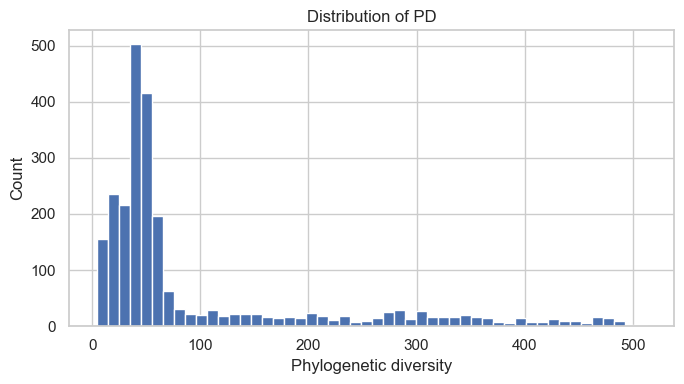

In [14]:
# histogram van de gekozen biodiversiteitsmaat
target = "PD"
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df_merge[target], bins=50, edgecolor="white")
ax.set_xlabel("Phylogenetic diversity")
ax.set_ylabel("Count")
ax.set_title("Distribution of PD")
plt.tight_layout()
plt.show()

### Correlatie berekenen
Variabelen t.o.v. target

In [15]:
corr_to_target = df_merge.corr(method = "pearson")[target].drop(labels = [target]) #correlatie berekenen van alle variabelen tov target en correlatie target met zichzelf laten vallen (is toch gelijk aan 1)
top = corr_to_target.reindex(corr_to_target.abs().sort_values(ascending=False).index) #sorteer van hoog naar laag
top.head(10)


clt_mean    -0.595241
SSTAnMean    0.526459
T_mean       0.518716
tas_mean     0.506403
OxyMean     -0.501464
o2_mean     -0.494494
po4_mean    -0.447619
no3_mean    -0.407352
SBTAnMean    0.403981
par_mean     0.357730
Name: PD, dtype: float64

variabelen t.o.v. elkaar

In [16]:
corr = df_merge.corr(numeric_only=True)

# corr omzetten naar lijst van paren
corr_pairs = corr.abs().unstack()

# zelf-correlaties verwijderen
corr_pairs = corr_pairs[corr_pairs < 1]

# top 10
top_pairs = corr_pairs.sort_values(ascending=False).drop_duplicates().head(10)

print(top_pairs)

long_deg           matched_CenterLong    0.999999
matched_CenterLat  lat_deg               0.999993
T_mean             SSTAnMean             0.999700
o2_mean            OxyMean               0.996973
IceConAnn          siconc_mean           0.992688
T_mean             tas_mean              0.988904
tas_mean           SSTAnMean             0.988185
o2_mean            T_mean                0.984634
SSTAnMean          o2_mean               0.984594
OxyMean            T_mean                0.983702
dtype: float64


## Volledig model

Dit model bevat data afkomstig van Aquamaps en Bio-ORACLE

### Target en variabelen selecteren

In [17]:
target = "PD" # Geselecteerde biodiversiteitsmaat om te voorspellen.
feature_cols = df_merge.columns.drop(["long_deg", "lat_deg", target]).tolist()

print(feature_cols)

['DepthMean', 'ClimZoneCode', 'SSTAnMean', 'SBTAnMean', 'SalinityMean', 'SalinityBMean', 'PrimProdMean', 'IceConAnn', 'OxyMean', 'OxyBMean', 'LandDist', 'Shelf', 'Slope', 'Abyssal', 'Coral', 'Estuary', 'Seamount', 'matched_CenterLong', 'matched_CenterLat', 'chl_mean', 'clt_mean', 'currentdirection_mean', 'currentvelocity_mean', 'dfe_mean', 'kdpar_mean', 'mlotst_mean', 'no3_mean', 'o2_mean', 'par_mean', 'phyc_mean', 'ph_mean', 'po4_mean', 'salinity_mean', 'siconc_mean', 'sithick_mean', 'si_mean', 'tas_mean', 'terrain_characteristics_aspect', 'terrain_characteristics_bea_mean', 'terrain_characteristics_rug', 'terrain_characteristics_slope', 'terrain_characteristics_topo', 'T_mean']


In [18]:
df_model = df_merge[[target] + feature_cols].copy()
print(f"Shape before cleaning: {df_model.shape}")
df_model.head()

Shape before cleaning: (2452, 44)


,PD,DepthMean,ClimZoneCode,SSTAnMean,SBTAnMean,SalinityMean,SalinityBMean,PrimProdMean,IceConAnn,OxyMean,...,siconc_mean,sithick_mean,si_mean,tas_mean,terrain_characteristics_aspect,terrain_characteristics_bea_mean,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean
0,11.830844,3998.0,5.0,-1.693377,-0.049802,33.934307,34.705566,1.153,0.708033,308.798553,...,0.731921,0.682407,103.700478,-12.067131,10.920937,-3936.972168,66.347260,0.933108,6.854279,-1.602750
1,11.830844,4079.0,5.0,-1.697129,-0.070504,33.976231,34.703896,1.141,0.702925,309.091431,...,0.727964,0.742742,104.054313,-11.786772,141.201179,-4093.388916,21.055542,0.320794,-12.930603,-1.620118
2,12.650381,4185.0,5.0,-1.658674,-0.071121,33.934555,34.703419,1.120,0.694178,311.400299,...,0.693648,0.713952,102.867443,-11.387081,216.269828,-4160.611328,14.489563,0.228825,5.524109,-1.582915
3,12.650381,4231.0,5.0,-1.629549,-0.072501,33.875896,34.703423,1.169,0.679715,313.670135,...,0.693803,0.720227,99.723148,-10.962065,224.836870,-4305.361328,4.413208,0.081748,1.760254,-1.579760
4,12.650381,4322.0,5.0,-1.620574,-0.066624,33.789886,34.710335,1.094,0.683326,315.589600,...,0.687315,0.703112,97.156055,-10.534314,300.267603,-4353.527832,10.302124,0.234018,-0.892456,-1.570748


### Ontbrekende waarden verwijderen

In [19]:
# Ontbrekende waarden worden als -9999 aangegeven in de dataset.
df_model.replace(-9999.0, np.nan, inplace=True)
df_model.replace(-9999, np.nan, inplace=True)

missing = df_model.isna().sum() # Ontbrekende waarden tellen.
print("Missing values per column:\n")
print(missing[missing > 0])

df_model.dropna(inplace=True) # Ontbrekende waarden verwijderen.
print(f"\nShape after dropping rows with NaN: {df_merge.shape}")

Missing values per column:

SSTAnMean                           172
SBTAnMean                           172
SalinityMean                        172
SalinityBMean                       172
PrimProdMean                        172
IceConAnn                           172
OxyMean                             172
OxyBMean                            172
chl_mean                            235
clt_mean                            235
currentdirection_mean               235
currentvelocity_mean                235
dfe_mean                            235
kdpar_mean                          237
mlotst_mean                         235
no3_mean                            235
o2_mean                             235
par_mean                            250
phyc_mean                           235
ph_mean                             235
po4_mean                            235
salinity_mean                       235
siconc_mean                         235
sithick_mean                        235
si_mean     

### Data splitten in training en test set

In [20]:
X = df_model[feature_cols]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2026
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")

Training samples: 1760
Test samples:     441


### Fitten van een Random Forest model op training set



In [24]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=1,
    max_features=0.5,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

### Hyperparameters optimaliseren

De bekomen hyperparameters in model hierboven gebruiken

 Code momenteel als markdown 

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

 #de hyperparameters optimaliseren 
param_grid = {
    "n_estimators": [200, 500, 800],
    "max_depth": [10, 20, 30, None],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", 0.3, 0.5]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

### Evalueren van rf op training en test set

Moet op beide goed zijn anders is het overgefit op training set

In [25]:
# voorspellingen maken op de test set
y_pred = rf.predict(X_test)

# Evalueren van een aantal metrieken
r2_train = rf.score(X_train, y_train)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Train R² : {r2_train:.4f}")
print(f"Test  R² : {r2:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"\nTrain–test gap: {r2_train - r2:.4f}")

Train R² : 0.9616
Test  R² : 0.7664
RMSE     : 56.0589
MAE      : 31.2549

Train–test gap: 0.1952


### Visualiseren resultaten

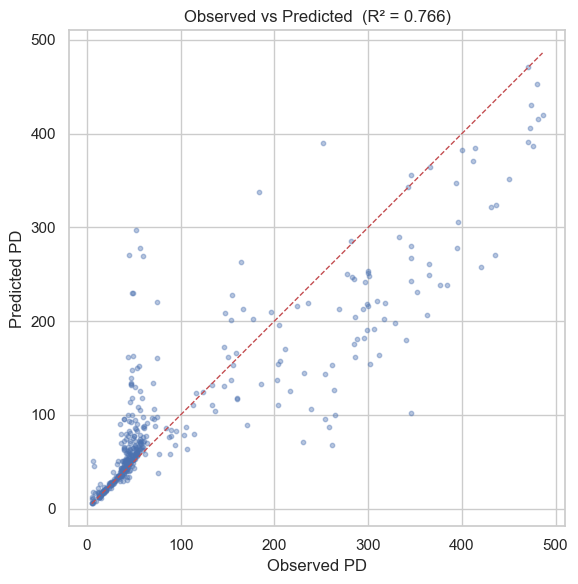

In [28]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, s=10, alpha=0.4)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1)
ax.set_xlabel("Observed PD")
ax.set_ylabel("Predicted PD")
ax.set_title(f"Observed vs Predicted  (R² = {r2:.3f})")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

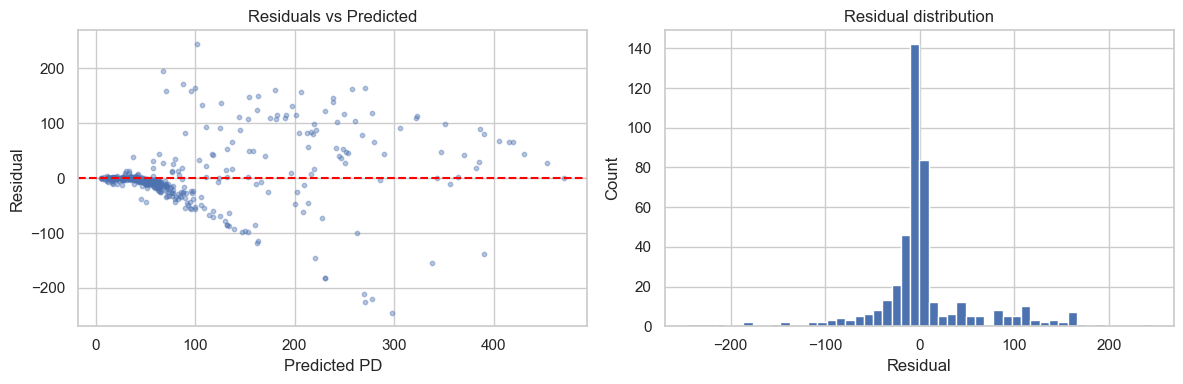

In [29]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred, residuals, s=10, alpha=0.4)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted PD")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=50, edgecolor="white")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.show()

### Feature importances van gefitte rf

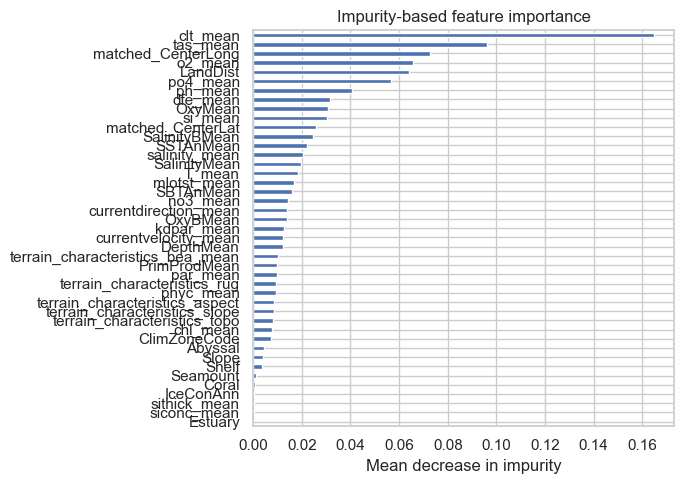

In [30]:
imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
imp.plot.barh(ax=ax)
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Impurity-based feature importance")
plt.tight_layout()
plt.show()

### Spatiale crossvalidatie

In [31]:
lat = df_merge.loc[df_model.index, "lat_deg"]
lon = df_merge.loc[df_model.index, "long_deg"]
lat_bin = pd.cut(lat, bins=np.arange(-90, 91, 10), labels=False)
lon_bin = pd.cut(lon, bins=np.arange(-180, 181, 10), labels=False)
spatial_blocks = lat_bin.astype(str) + "_" + lon_bin.astype(str)

print(f"\nSpatial blocks (10°×10° grid): {spatial_blocks.nunique()} unique blocks")

gkf = GroupKFold(n_splits=5)
spatial_cv = cross_val_score(
    rf, X, y, cv=gkf, groups=spatial_blocks, scoring="r2", n_jobs=-1,
)
print("Spatial  5-fold CV R² scores:", np.round(spatial_cv, 4))
print(f"Mean R²: {spatial_cv.mean():.4f}  ±  {spatial_cv.std():.4f}")


Spatial blocks (10°×10° grid): 422 unique blocks
Spatial  5-fold CV R² scores: [0.6544 0.7436 0.576  0.6784 0.7208]
Mean R²: 0.6746  ±  0.0584


## Model met minder variabelen

Dit model bevat enkel variabelen van Bio-ORACLE. Daarnaast worden de variabelen die niet beschikbaar zijn in de toekomst ook verwijderd. Op dit model wordt ook dimensionaliteitsreductie uitgevoerd.

Dimensionaliteit reduceren --> uitkijken voor bias

### Dataframe met enkel Bio-ORACLE

In [38]:
df_bio = df_biooracle
df_bio.columns

Index(['marine_species_richness', 'PD', 'co1_genetic_diversity_mean',
       'long_deg', 'lat_deg', 'chl_max', 'chl_mean', 'chl_min', 'clt_max',
       'clt_mean', 'clt_min', 'currentdirection_max', 'currentdirection_mean',
       'currentdirection_min', 'currentvelocity_ltmax', 'currentvelocity_max',
       'currentvelocity_mean', 'currentvelocity_min', 'dfe_max', 'dfe_mean',
       'dfe_min', 'kdpar_max', 'kdpar_mean', 'kdpar_min', 'mlotst_max',
       'mlotst_mean', 'mlotst_min', 'no3_max', 'no3_mean', 'no3_min', 'o2_max',
       'o2_mean', 'o2_min', 'par_mean', 'par_min', 'phyc_max', 'phyc_mean',
       'phyc_min', 'ph_max', 'ph_mean', 'ph_min', 'po4_max', 'po4_mean',
       'po4_min', 'salinity_ltmax', 'salinity_ltmin', 'salinity_max',
       'salinity_mean', 'salinity_min', 'salinity_range', 'siconc_max',
       'siconc_mean', 'siconc_min', 'sithick_max', 'sithick_mean',
       'sithick_min', 'si_max', 'si_mean', 'si_min', 'tas_max', 'tas_mean',
       'tas_min', 'terrain_charact

Data verwijderen die onnodig is: andere biodiversiteitsmaten, enkel gemiddeldes overhouden

In [39]:
cols_to_drop = (df_bio.filter(regex=r'(?i)(min|max|range)').columns.tolist() + ["co1_genetic_diversity_mean", "marine_species_richness"])
df_bio = df_bio.drop(cols_to_drop, axis = 1)

df_bio.columns

Index(['PD', 'long_deg', 'lat_deg', 'chl_mean', 'clt_mean',
       'currentdirection_mean', 'currentvelocity_mean', 'dfe_mean',
       'kdpar_mean', 'mlotst_mean', 'no3_mean', 'o2_mean', 'par_mean',
       'phyc_mean', 'ph_mean', 'po4_mean', 'salinity_mean', 'siconc_mean',
       'sithick_mean', 'si_mean', 'tas_mean', 'terrain_characteristics_aspect',
       'terrain_characteristics_bea_mean', 'terrain_characteristics_rug',
       'terrain_characteristics_slope', 'terrain_characteristics_topo',
       'T_mean'],
      dtype='object')

Variabelen verwijderen die niet beschikbaar zijn in de toekomst

In [40]:
cols_to_drop = (df_bio.filter(regex=r'(?i)(min|max|range)').columns.tolist() + ["kdpar_mean", "par_mean", "terrain_characteristics_aspect", "terrain_characteristics_bea_mean", "terrain_characteristics_rug", "terrain_characteristics_slope", "terrain_characteristics_topo"])
df_bio = df_bio.drop(cols_to_drop, axis = 1)

df_bio.columns

Index(['PD', 'long_deg', 'lat_deg', 'chl_mean', 'clt_mean',
       'currentdirection_mean', 'currentvelocity_mean', 'dfe_mean',
       'mlotst_mean', 'no3_mean', 'o2_mean', 'phyc_mean', 'ph_mean',
       'po4_mean', 'salinity_mean', 'siconc_mean', 'sithick_mean', 'si_mean',
       'tas_mean', 'T_mean'],
      dtype='object')

In [41]:
target_red = "PD" # Geselecteerde biodiversiteitsmaat om te voorspellen.
feature_cols_red = df_merge.columns.drop(["long_deg", "lat_deg", "PD"]).tolist()

df_red = df_merge[[target_red] + feature_cols_red].copy()
print(f"Shape before cleaning: {df_red.shape}")
df_red.describe()

Shape before cleaning: (2452, 44)


,PD,DepthMean,ClimZoneCode,SSTAnMean,SBTAnMean,SalinityMean,SalinityBMean,PrimProdMean,IceConAnn,OxyMean,...,siconc_mean,sithick_mean,si_mean,tas_mean,terrain_characteristics_aspect,terrain_characteristics_bea_mean,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean
count,2452.000000,2452.000000,2452.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,...,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2.217000e+03,2217.000000,2217.000000
mean,97.907775,3395.364192,4.914763,16.134410,2.069516,34.374631,34.574813,4.597464,0.054981,257.412446,...,0.059461,0.070197,14.698095,14.624145,183.500427,-3748.862966,94.427332,1.179893e+00,-2.727722,16.382824
std,115.578176,1807.135985,2.244826,10.626096,4.586234,1.838647,1.254989,5.905518,0.162398,54.275344,...,0.173575,0.215610,26.476457,11.465120,104.334155,1538.097895,106.862539,1.406274e+00,76.048905,10.565343
min,4.177602,0.000000,0.000000,-1.790485,-1.731767,4.524624,5.264678,0.096000,0.000000,196.910355,...,0.000000,0.000000,0.656868,-16.241398,0.182399,-7138.611328,0.000000,2.484808e-17,-658.309052,-1.838033
25%,34.835263,2556.000000,4.000000,6.128384,0.496306,33.835644,34.677283,1.642750,0.000000,207.841774,...,0.000000,0.000000,1.594731,5.300397,93.788117,-4841.555664,30.402771,3.307500e-01,-28.128448,6.396754
50%,47.090843,3944.000000,5.000000,18.972795,1.054664,34.463772,34.698887,2.995500,0.000000,236.162773,...,0.000000,0.000000,2.670603,17.737980,184.875910,-4115.527832,62.715210,7.419182e-01,-1.149323,19.306662
75%,96.951054,4753.250000,7.000000,26.209159,1.656099,35.316861,34.722000,5.623750,0.000000,308.180664,...,0.000000,0.000000,13.881882,25.288107,274.005903,-3187.027832,117.663208,1.471722e+00,19.500183,26.387225
max,512.751559,7660.000000,8.000000,29.790718,29.696379,38.469193,40.475456,99.214002,0.965107,394.526001,...,0.963429,1.794409,121.972284,28.490869,359.858364,0.000000,1098.482654,1.466965e+01,748.565994,30.261832


Hier nog eens opnieuw de missende waarden verwijderen, want df is weer gemaakt op basis van de kolommen waar die waarden nog niet waren verwijderd. 

In [42]:
df_red.replace(-9999.0, np.nan, inplace=True)
df_red.replace(-9999, np.nan, inplace=True)

missing = df_red.isna().sum()
print("Missende waarden per kolom:\n")
print(missing[missing > 0])

df_red.dropna(inplace=True)
print(f"\nShape after dropping rows with NaN: {df_red.shape}")

Missende waarden per kolom:

SSTAnMean                           172
SBTAnMean                           172
SalinityMean                        172
SalinityBMean                       172
PrimProdMean                        172
IceConAnn                           172
OxyMean                             172
OxyBMean                            172
chl_mean                            235
clt_mean                            235
currentdirection_mean               235
currentvelocity_mean                235
dfe_mean                            235
kdpar_mean                          237
mlotst_mean                         235
no3_mean                            235
o2_mean                             235
par_mean                            250
phyc_mean                           235
ph_mean                             235
po4_mean                            235
salinity_mean                       235
siconc_mean                         235
sithick_mean                        235
si_mean    

In [43]:
print(X.isna().sum().sort_values(ascending=False).head(10))

DepthMean        0
ClimZoneCode     0
SSTAnMean        0
SBTAnMean        0
SalinityMean     0
SalinityBMean    0
PrimProdMean     0
IceConAnn        0
OxyMean          0
OxyBMean         0
dtype: int64


In [44]:
X_red = df_red[feature_cols_red]
y_red = df_red[target_red]


### Recursive feature elimination 

RMSE en spatiale cross validatie

Als markdown

from sklearn.feature_selection import RFECV

# Random Forest
estimator = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

# RFECV met spatial CV + RMSE
selector = RFECV(
    estimator,
    step=1,
    cv=gkf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

selector.fit(X_red, y_red, groups=spatial_blocks)

print(f"Optimal number of features: {selector.n_features_}")

selected_features_RFECV = X.columns[selector.support_]
print("Selected features:", list(selected_features_RFECV))

### Dataset met geselecteerde features

In [46]:
selected_features_RFECV = [ # Dit zijn de variabelen die we hier selecteren om de biodiversiteit te voorspellen.
  "SalinityMean",
  "OxyBMean",
  "LandDist",
  "matched_CenterLong",
  "matched_CenterLat",
  "clt_mean",
  "dfe_mean",
  "o2_mean",
  "ph_mean",
  "po4_mean",
  "si_mean",
  "tas_mean"
]

### Data splitten in training en test set

In [55]:
X_selected = X_red[selected_features_RFECV]
y_selected = y_red

X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected, y_selected, test_size = 0.2, random_state = 2026
)

print(f"Training set: {X_train_selected.shape[0]}")
print(f"Test set: {X_test_selected.shape[0]}")

Training set: 1760
Test set: 441


### Fitten van een rf model op training set met enkel geselecteerde features

In [56]:
rf_selected_RFECV = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=1,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf_selected_RFECV.fit(X_train_selected, y_train_selected)

# Feature importances
imp = pd.Series(
    rf_selected_RFECV.feature_importances_,
    index=selected_features_RFECV
).sort_values()

print(imp)

OxyBMean              0.034104
matched_CenterLat     0.045692
SalinityMean          0.048557
si_mean               0.053615
dfe_mean              0.058322
ph_mean               0.061011
po4_mean              0.084967
LandDist              0.088509
o2_mean               0.098539
matched_CenterLong    0.101875
tas_mean              0.119291
clt_mean              0.205517
dtype: float64


### Hyperparameters optimaliseren

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf= RandomForestRegressor(random_state=42)

# de hyperparameters optimaliseren 
param_grid = {
    "n_estimators": [200, 500, 800],
    "max_depth": [10, 20, 30, None],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", 0.3, 0.5]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train_selected, y_train_selected)

print(grid.best_params_)

### Evalueren rf op training en test set



In [57]:
y_pred_sel = rf_selected_RFECV.predict(X_test_selected)

r2_train_sel = rf_selected_RFECV.score(X_train_selected, y_train_selected)
rmse_sel = np.sqrt(mean_squared_error(y_test_selected, y_pred_sel))
mae_sel = mean_absolute_error(y_test_selected, y_pred_sel)
r2_sel = r2_score(y_test_selected, y_pred_sel)

print(f"Train R²: {r2_train_sel:.4f}")
print(f"Test R²: {r2_sel:.4f}")
print(f"RMSE: {rmse_sel:.4f}")
print(f"MAE: {mae_sel:.4f}")
print(f"\nTrain-test gap: {r2_train_sel - r2_sel:.4f}")

Train R²: 0.9637
Test R²: 0.7765
RMSE: 54.8346
MAE: 29.4584

Train-test gap: 0.1872


### Visualisatie 

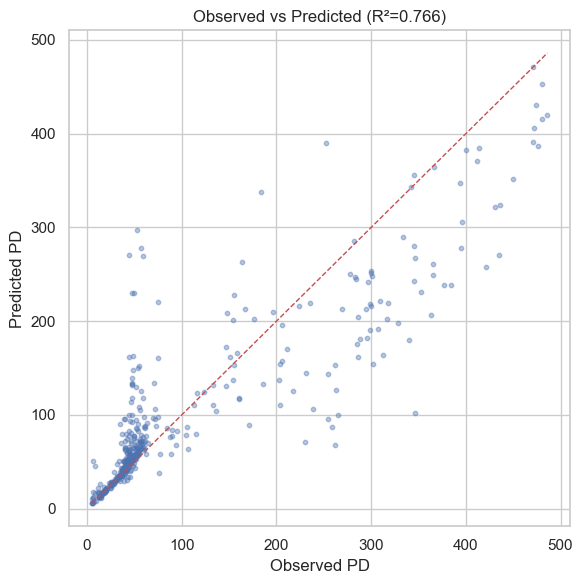

In [58]:
fig, ax = plt.subplots(figsize = (6,6))
ax.scatter(y_test_selected, y_pred, alpha=0.4, s = 10)
lims = [min(y_test_selected.min(), y_pred.min()), max(y_test_selected.max(), y_pred.max())]
ax.plot(lims, lims, 'r--' , linewidth=1)
ax.set_xlabel("Observed PD")
ax.set_ylabel("Predicted PD")
ax.set_title(f"Observed vs Predicted (R²={r2:.3f})")
plt.tight_layout()
plt.show()

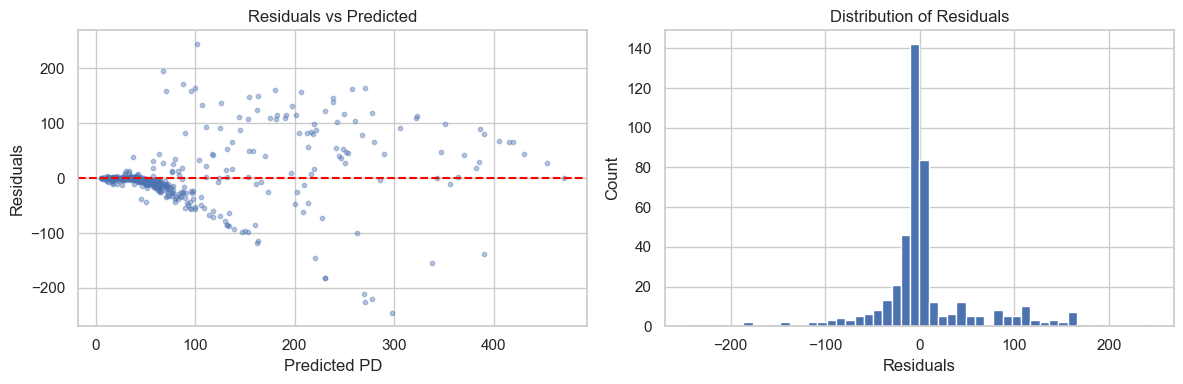

In [53]:
residuals_red = y_test_selected - y_pred

fig, axes = plt.subplots(1,2, figsize = (12,4))

axes[0].scatter(y_pred, residuals_red, alpha=0.4, s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Predicted PD")
axes[0].set_ylabel("Residuals") 
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals_red, bins=50, edgecolor='white')
axes[1].set_xlabel("Residuals") 
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Residuals")

plt.tight_layout()
plt.show()

### Feature importance

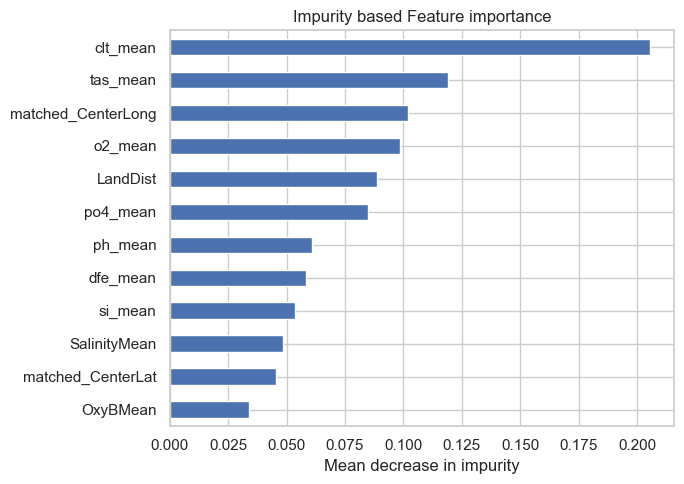

In [59]:
imp_red = pd.Series(rf_selected_RFECV.feature_importances_, index=selected_features_RFECV).sort_values()

fig, ax = plt.subplots(figsize=(7,5))
imp_red.plot.barh(ax=ax)
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Impurity based Feature importance")
plt.tight_layout()
plt.show()

## Definitieve model
Nu weten we adhv het model gemaakt van train en test set dat het een goeie performantie heeft. Nu kunnen we het model opnieuw met alle data maken(niet meer opgesplits in train en test). Op die manier gaat er geen informatie verloren.

In [62]:
rf_def = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf_def.fit(X_selected, y_selected)

# Feature importances
imp = pd.Series(
    rf_def.feature_importances_,
    index=selected_features_RFECV
).sort_values()

print(imp)

OxyBMean              0.027970
SalinityMean          0.045391
ph_mean               0.046309
matched_CenterLat     0.046562
dfe_mean              0.047278
si_mean               0.054270
po4_mean              0.074322
LandDist              0.088824
matched_CenterLong    0.102026
o2_mean               0.119328
tas_mean              0.119585
clt_mean              0.228135
dtype: float64


### Hyperparameters optimaliseren

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf= RandomForestRegressor(random_state=42)

# de hyperparameters optimaliseren 
param_grid = {
    "n_estimators": [200, 500, 800],
    "max_depth": [10, 20, 30, None],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", 0.3, 0.5]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_selected, y_selected)

print(grid.best_params_)

## Toekomst

Toekomstige biodiversiteit voorspellen (SSP119, jaren 2050-2060)

In [63]:
toekomst = pd.read_csv(DATA_DIR / "PD_2050-60_SSP119.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Emma\\2. Bestanden\\1. UGent\\3e bachelor (2025-2026)\\2e semester\\Bachelorproef\\Programmeergedeelte\\Bachelorproef\\Data\\PD_2050-60_SSP119.csv'

In [ ]:
X_future = toekomst[X_train_selected.columns]

In [ ]:
PD_toekomst = rf_selected_RFECV.predict(X_future)

In [ ]:
toekomst["PD"] = PD_toekomst

In [ ]:
toekomst.head()

,Unnamed: 0,clt_mean,dfe_mean,mlotst_mean,o2_mean,phyc_mean,ph_mean,po4_mean,si_mean,salinity_mean,...,long_deg,lat_deg,DepthMean,LandDist,Slope,kdpar_mean,par_mean,terrain_characteristics_rug,terrain_characteristics_slope,SR
0,0,0.689485,0.000391,61.532763,314.002378,1.237505,7.970945,2.152274,0.729408,33.931405,...,-171.74579,-71.23536,3998,636,730.228795,0.060146,37.450932,66.347260,0.933108,37.940
1,1,0.700666,0.000376,63.236088,315.845510,1.337427,7.972867,2.166582,0.722381,33.946644,...,-167.88679,-71.23536,4079,742,0.000000,0.062998,29.998841,21.055542,0.320794,37.648
2,2,0.703526,0.000368,63.562959,315.316479,1.259565,7.973096,2.168482,0.690216,33.945152,...,-164.02779,-71.23536,4185,708,0.000000,0.072465,32.604841,14.489563,0.228825,40.278
3,3,0.697370,0.000348,59.205664,318.284476,1.335023,7.976109,2.159415,0.696709,33.912422,...,-160.16879,-71.23536,4231,661,0.000000,0.067391,31.006588,4.413208,0.081748,39.816
4,4,0.692536,0.000343,60.567262,317.223787,1.358980,7.975836,2.158386,0.697316,33.883653,...,-156.30979,-71.23536,4322,608,0.000000,0.066070,33.850906,10.302124,0.234018,39.612


Distributie van PD in de toekomst

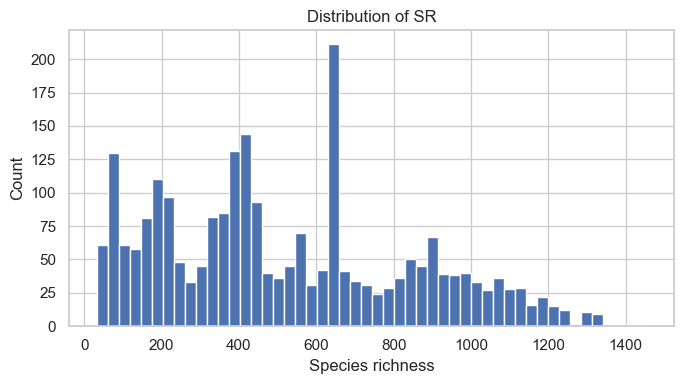

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(toekomst["PD"], bins=50, edgecolor="white")
ax.set_xlabel("Phylogenetic diversity")
ax.set_ylabel("Count")
ax.set_title("Distribution of PD")
plt.tight_layout()
plt.show()

Een kaartje maken om de biodiversiteit in de toekomst te visualiseren over de hele wereld

In [ ]:
import plotly.express as px
import plotly.io as pio

In [ ]:
fig = px.scatter_geo(
    toekomst,
    lat="lat_deg",
    lon="long_deg",
    color="PD",   # kleurt de punten op basis van biodiversiteit
    hover_name="PD",  
    projection="natural earth",    # mooie wereldkaart
    title = "Phylogenetic diversity"
)
fig.show()